# Clasificación de supervivencia en Titanic

| Integrante | Tareas realizadas |
|---|---|
| Nayeli Suarez | Limpieza de datos, feature engineering y pipeline |
| Amy Peñafiel | Entrenamiento de modelos y búsqueda de hiperparámetros |
| Maria Jose Beltran | Evaluación, métricas, matriz de confusión y curva ROC |
| Victor Briones | Análisis de overfitting, importancia de variables e informe |



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("\nTrain head:")
print(train.head(2))
print("\nTrain info:")
print(train.info())

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)


Train shape: (891, 12)
Test shape: (418, 11)

Train head:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   

   Parch     Ticket     Fare Cabin Embarked  
0      0  A/5 21171   7.2500   NaN        S  
1      0   PC 17599  71.2833   C85        C  

Train info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibS

In [ ]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print(train.shape)
print(test.shape)
train.head()


(891, 12)
(418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Feature engineering

Se crean variables dentro del pipeline para evitar data leakage. Las variables nuevas incluyen título, tamaño familiar, pasajero solo, tarifa por persona, cabina registrada, cubierta, interacción edad-clase y tamaño del grupo de ticket.


In [ ]:
def add_features(X):
    X = X.copy()
    X['Title'] = X['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False).fillna('Unknown')
    X['Title'] = X['Title'].where(X['Title'].isin(['Mr', 'Miss', 'Mrs', 'Master']), 'Rare')
    X['FamilySize'] = X['SibSp'] + X['Parch'] + 1
    X['IsAlone'] = (X['FamilySize'] == 1).astype(int)
    X['FarePerPerson'] = X['Fare'] / X['FamilySize']
    X['HasCabin'] = X['Cabin'].notna().astype(int)
    X['Deck'] = X['Cabin'].astype(str).str[0]
    X.loc[X['Cabin'].isna(), 'Deck'] = 'Unknown'
    X['AgeClass'] = X['Age'] * X['Pclass']
    X['TicketGroupSize'] = X.groupby('Ticket')['Ticket'].transform('count')
    return X

numeric_features = [
    'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize',
    'IsAlone', 'FarePerPerson', 'HasCabin', 'AgeClass', 'TicketGroupSize'
]

categorical_features = ['Sex', 'Embarked', 'Title', 'Deck']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = Pipeline(steps=[
    ('features', FunctionTransformer(add_features, validate=False)),
    ('columns', ColumnTransformer(transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]))
])


## División de datos y modelos

La evaluación se realiza sobre una partición de `train.csv`, porque `test.csv` no incluye la variable `Survived`.


In [ ]:
X = train.drop(columns=['Survived'])
y = train['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42)
}


In [ ]:
param_spaces = {
    'Decision Tree': {
        'model__max_depth': [3, 5, 7],
        'model__min_samples_split': [2, 5],
        'model__min_samples_leaf': [1, 2]
    },
    'Random Forest': {
        'model__n_estimators': [80, 120],
        'model__max_depth': [5, None],
        'model__min_samples_leaf': [1, 2]
    },
    'Gradient Boosting': {
        'model__n_estimators': [50, 80],
        'model__learning_rate': [0.05, 0.1],
        'model__max_depth': [2, 3]
    }
}

best_models = {}
search_results = {}

for name, estimator in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', estimator)
    ])

    if name == 'Decision Tree':
        search = GridSearchCV(pipe, param_spaces[name], cv=5, scoring='f1_macro', n_jobs=1)
        search.fit(X_train, y_train)
        best_models[name] = search.best_estimator_
        search_results[name] = {
            'method': 'GridSearchCV',
            'best_params': search.best_params_,
            'best_score_f1_macro': search.best_score_
        }
    elif name in ['Random Forest', 'Gradient Boosting']:
        search = RandomizedSearchCV(
            pipe, param_spaces[name], n_iter=4, cv=5,
            scoring='f1_macro', random_state=42, n_jobs=1
        )
        search.fit(X_train, y_train)
        best_models[name] = search.best_estimator_
        search_results[name] = {
            'method': 'RandomizedSearchCV',
            'best_params': search.best_params_,
            'best_score_f1_macro': search.best_score_
        }
    else:
        pipe.fit(X_train, y_train)
        best_models[name] = pipe

search_results


{'Decision Tree': {'method': 'GridSearchCV',
  'best_params': {'model__max_depth': 5,
   'model__min_samples_leaf': 1,
   'model__min_samples_split': 5},
  'best_score_f1_macro': np.float64(0.8002529399442706)},
 'Random Forest': {'method': 'RandomizedSearchCV',
  'best_params': {'model__n_estimators': 120,
   'model__min_samples_leaf': 2,
   'model__max_depth': None},
  'best_score_f1_macro': np.float64(0.8106709242674459)},
 'Gradient Boosting': {'method': 'RandomizedSearchCV',
  'best_params': {'model__n_estimators': 80,
   'model__max_depth': 3,
   'model__learning_rate': 0.1},
  'best_score_f1_macro': np.float64(0.8102981543001302)}}

In [ ]:
results = []

for name, model in best_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    train_f1 = f1_score(y_train, model.predict(X_train), average='macro')
    cv_f1 = cross_val_score(model, X_train, y_train, cv=5, scoring='f1_macro', n_jobs=1).mean()

    results.append({
        'Modelo': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision macro': precision_score(y_test, y_pred, average='macro'),
        'Recall macro': recall_score(y_test, y_pred, average='macro'),
        'F1 macro': f1_score(y_test, y_pred, average='macro'),
        'AUC-ROC': roc_auc_score(y_test, y_proba),
        'Train F1 macro': train_f1,
        'CV F1 macro': cv_f1,
        'Brecha Train-CV': train_f1 - cv_f1
    })

results_df = pd.DataFrame(results).sort_values('F1 macro', ascending=False)
results_df


,Modelo,Accuracy,Precision macro,Recall macro,F1 macro,AUC-ROC,Train F1 macro,CV F1 macro,Brecha Train-CV
3,Logistic Regression,0.832402,0.825439,0.817721,0.821095,0.867457,0.828349,0.804476,0.023874
0,Decision Tree,0.821229,0.813360,0.805929,0.809168,0.839130,0.870769,0.800253,0.070517
1,Random Forest,0.810056,0.806638,0.786034,0.793274,0.845916,0.915454,0.810671,0.104783
2,Gradient Boosting,0.787709,0.777126,0.770553,0.773388,0.843874,0.918473,0.810298,0.108175


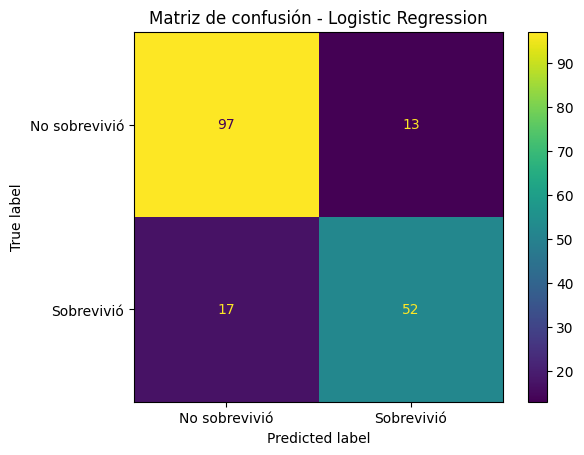

In [ ]:
best_model_name = results_df.iloc[0]['Modelo']
best_model = best_models[best_model_name]

y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

ConfusionMatrixDisplay(cm, display_labels=['No sobrevivió', 'Sobrevivió']).plot(values_format='d')
plt.title(f'Matriz de confusión - {best_model_name}')
plt.show()


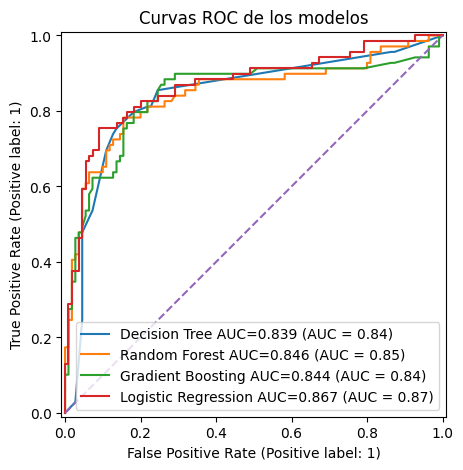

In [ ]:
plt.figure(figsize=(7, 5))

for name, model in best_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    RocCurveDisplay.from_predictions(
        y_test, y_proba, name=f'{name} AUC={auc:.3f}', ax=plt.gca()
    )

plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('Curvas ROC de los modelos')
plt.show()


In [ ]:
model_step = best_model.named_steps['model']
column_transformer = best_model.named_steps['preprocessor'].named_steps['columns']
feature_names = list(column_transformer.get_feature_names_out())

if hasattr(model_step, 'feature_importances_'):
    importances = model_step.feature_importances_
else:
    importances = abs(model_step.coef_[0])

importance_df = pd.DataFrame({
    'Variable': feature_names,
    'Importancia': importances
}).sort_values('Importancia', ascending=False).head(10)

importance_df


,Variable,Importancia
16,cat__Title_Master,1.219739
18,cat__Title_Mr,1.215280
11,cat__Sex_female,0.905718
12,cat__Sex_male,0.846554
25,cat__Deck_E,0.766577
27,cat__Deck_G,0.751880
24,cat__Deck_D,0.720136
19,cat__Title_Mrs,0.575826
0,num__Pclass,0.419169
2,num__SibSp,0.355912


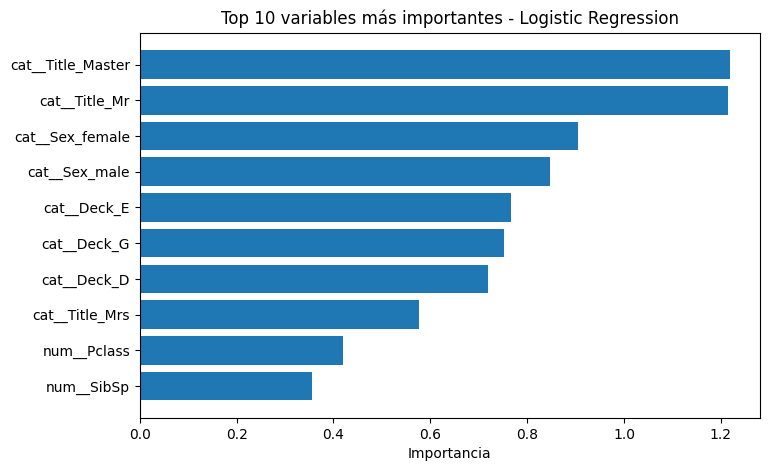

In [ ]:
plt.figure(figsize=(8, 5))
plt.barh(importance_df['Variable'], importance_df['Importancia'])
plt.gca().invert_yaxis()
plt.title(f'Top 10 variables más importantes - {best_model_name}')
plt.xlabel('Importancia')
plt.show()


In [ ]:
# Entrenamiento final con todo train.csv y predicción para test.csv
final_model = best_model
final_model.fit(X, y)

submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': final_model.predict(test)
})

submission.to_csv('predicciones_test.csv', index=False)
submission.head()


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
